In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
df = pd.read_csv("../../data/meta/go_emotions_meta.csv")

print("------------")
print("GoEmotions")
print("Shape: ", df.shape)
print("COLS")
print(list(df.columns))
display(df)

------------
GoEmotions
Shape:  (54234, 299)
COLS
['UNCLEAN_TEXT_PT', 'BASE_TEXT_PT', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'id', 'text', 'UNCLEAN_TEXT_EN', 'BASE_TEXT_EN', 'doc', 'n_words', 'n_sentences', 'words_per_sentence', 'n_characters', 'reading_time', 'uppercase_ratio', 'char_repetition_ratio', 'avg_letters_per_word', 'avg_syllables_per_word', 'total_punct', 'punct_per_word', 'punct_per_sentence', 'exclam', 'quest', 'rarest_word', 'most_common_word', 'avg_freq', 'freq_disp', 'ttr', 'stopword_ratio', 'n_unique_words', 'mean_unique_word_length', 'flesch_portuguese', 'NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'CCONJ', 'SCONJ', 'NUM', 'PROPN', 'INTJ', 'mean_verbs_per_sentence'

,UNCLEAN_TEXT_PT,BASE_TEXT_PT,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,relief_jaccard_mean,relief_jaccard_max,remorse_jaccard_mean,remorse_jaccard_max,sadness_jaccard_mean,sadness_jaccard_max,surprise_jaccard_mean,surprise_jaccard_max,neutral_jaccard_mean,neutral_jaccard_max
0,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,0,0,0,0,1,0,0,0,...,0.008109,0.034483,0.009622,0.033333,0.009559,0.054054,0.011748,0.040000,0.007700,0.040000
1,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,0,0,0,0,0,0,0,0,...,0.000000,0.000000,0.005739,0.047619,0.002469,0.037037,0.000000,0.000000,0.000000,0.000000
2,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,0,0,0,0,0,0,0,0,...,0.034446,0.096774,0.035924,0.100000,0.044744,0.107143,0.036009,0.096774,0.013464,0.043478
3,Tanto tempo economizado. Não.,tanto tempo economizado nao,0,0,0,0,0,0,0,1,...,0.002778,0.041667,0.004444,0.033333,0.002899,0.043478,0.006303,0.058824,0.000000,0.000000
4,Os emotes têm uma quantidade ridícula de esfor...,emotes tem uma quantidade ridicula esforco que...,0,0,0,0,0,0,0,0,...,0.025082,0.062500,0.028918,0.064516,0.036117,0.096774,0.030729,0.096774,0.005121,0.043478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54229,[NOME]. Não tenho certeza se você se sentirá d...,nome nao tenho certeza voce sentira mesma mane...,0,0,0,0,0,0,1,0,...,0.008077,0.034483,0.009880,0.034483,0.007531,0.030303,0.008048,0.035714,0.000000,0.000000
54230,Eu posso ver porque! Eu ficaria totalmente ofe...,posso ver porque ficaria totalmente ofendido t...,0,0,0,1,0,0,0,0,...,0.005280,0.043478,0.010562,0.047619,0.002469,0.037037,0.000000,0.000000,0.000000,0.000000
54231,Aproximar-se não funciona a menos que você sej...,aproximar-se nao funciona menos que voce seja ...,0,0,0,0,0,0,0,0,...,0.025132,0.062500,0.032933,0.058824,0.024584,0.060606,0.018022,0.060606,0.000000,0.000000
54232,Hahaha perfeito.,hahaha perfeito,1,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
emotions = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise','neutral'
]

methods = ["tfidf", "emb", "jaccard"]

def get_features_by_method(method):
    return [col for col in df.columns if f"_{method}_" in col]

X_full = df
y_full = df[emotions]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

def evaluate_method(method):
    feats = get_features_by_method(method)

    Xtr = X_train[feats].fillna(0)
    Xte = X_test[feats].fillna(0)

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    scores = []

    for emo in emotions:
        model = LogisticRegression(max_iter=1000)

        model.fit(Xtr, y_train[emo])
        preds = model.predict(Xte)

        score = f1_score(y_test[emo], preds, zero_division=0)
        scores.append(score)

    return np.mean(scores)

results = {}

for m in methods:
    print(f"Evaluating {m}...")
    results[m] = evaluate_method(m)

print("\n=== RESULTADOS ===")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Evaluating tfidf...
Evaluating emb...
Evaluating jaccard...

=== RESULTADOS ===
tfidf: 0.0129
emb: 0.1265
jaccard: 0.0073


In [11]:
all_similarity_feats = [col for col in df.columns if any(x in col for x in ["_tfidf_", "_emb_", "_jaccard_"])]

X = df[all_similarity_feats].fillna(0)
y = df[emotions]

importances = np.zeros(len(all_similarity_feats))

for emo in tqdm(emotions):
    model = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    model.fit(X, y[emo])
    importances += model.feature_importances_

importances /= len(emotions)

feat_importance_df = pd.DataFrame({
    "feature": all_similarity_feats,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_importance_df.head(20))

100%|██████████| 28/28 [03:19<00:00,  7.14s/it]

                  feature  importance
86     gratitude_emb_mean    0.011002
87      gratitude_emb_max    0.010567
64      approval_emb_mean    0.010231
110      neutral_emb_mean    0.010019
90           joy_emb_mean    0.009945
78       disgust_emb_mean    0.009834
65       approval_emb_max    0.009737
76   disapproval_emb_mean    0.009558
91            joy_emb_max    0.009488
111       neutral_emb_max    0.009417
96      optimism_emb_mean    0.009399
95    nervousness_emb_max    0.009375
56    admiration_emb_mean    0.009317
88         grief_emb_mean    0.009155
77    disapproval_emb_max    0.009063
70     curiosity_emb_mean    0.009040
68     confusion_emb_mean    0.009034
82    excitement_emb_mean    0.008997
99          pride_emb_max    0.008857
69      confusion_emb_max    0.008840


In [13]:
feat_importance_df["method"] = feat_importance_df["feature"].apply(
    lambda x: x.split("_")[-2]  # tfidf, emb, jaccard
)

method_importance = feat_importance_df.groupby("method")["importance"].mean()

print("\n=== IMPORTÂNCIA MÉDIA POR MÉTODO ===")
print(method_importance.sort_values(ascending=False))


=== IMPORTÂNCIA MÉDIA POR MÉTODO ===
method
emb        0.008654
tfidf      0.005011
jaccard    0.004192
Name: importance, dtype: float64


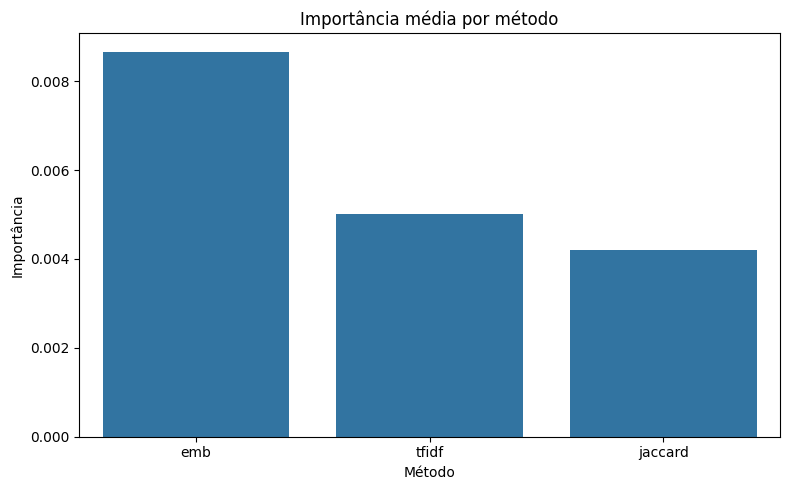

In [19]:
method_importance = method_importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=method_importance.index,
    y=method_importance.values
)

plt.title("Importância média por método")
plt.ylabel("Importância")
plt.xlabel("Método")

plt.tight_layout()
plt.show()

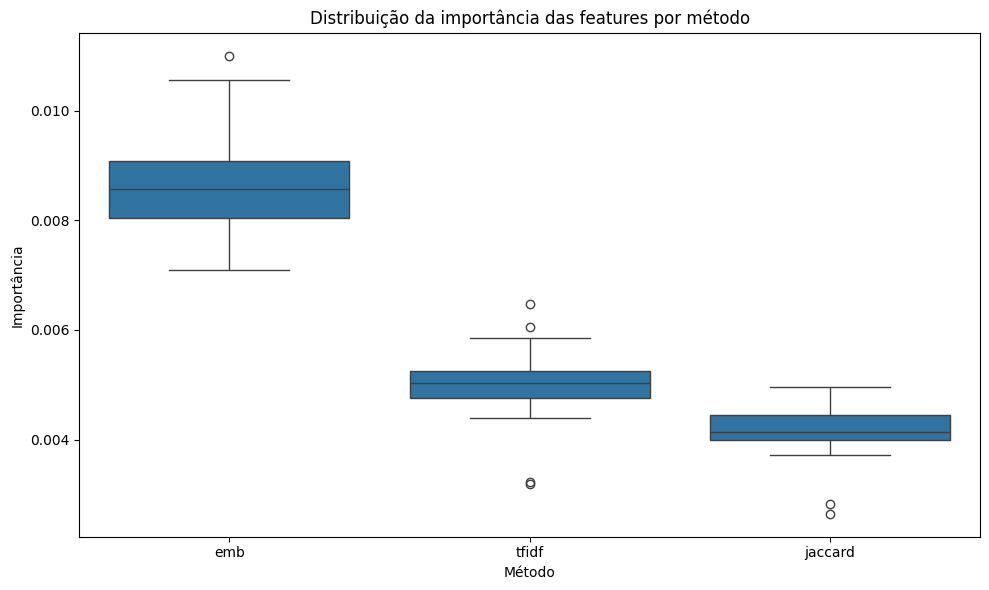

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=feat_importance_df,
    x="method",
    y="importance"
)

plt.title("Distribuição da importância das features por método")
plt.ylabel("Importância")
plt.xlabel("Método")

plt.tight_layout()
plt.show()

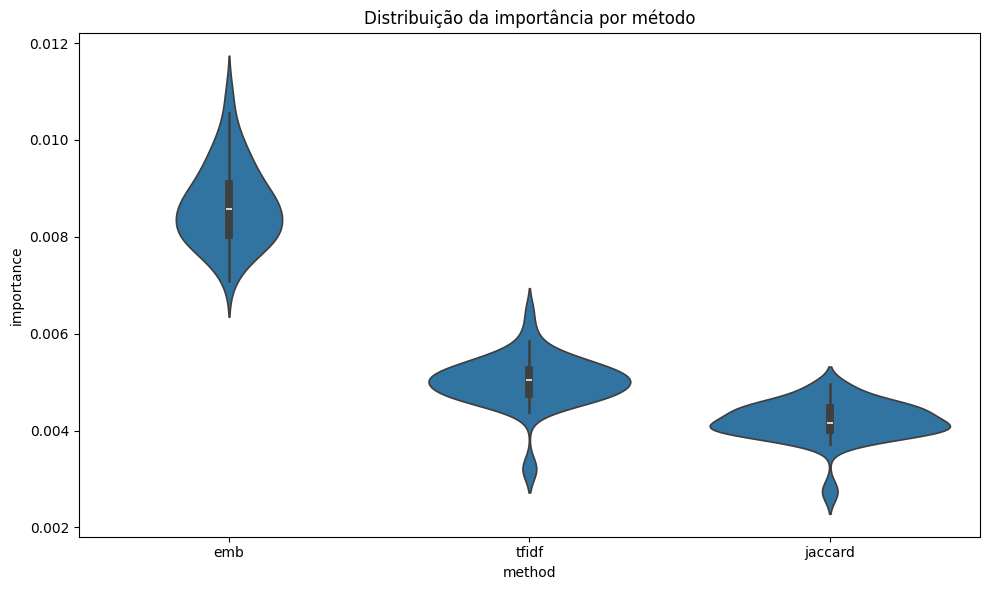

In [21]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=feat_importance_df,
    x="method",
    y="importance"
)

plt.title("Distribuição da importância por método")
plt.tight_layout()
plt.show()

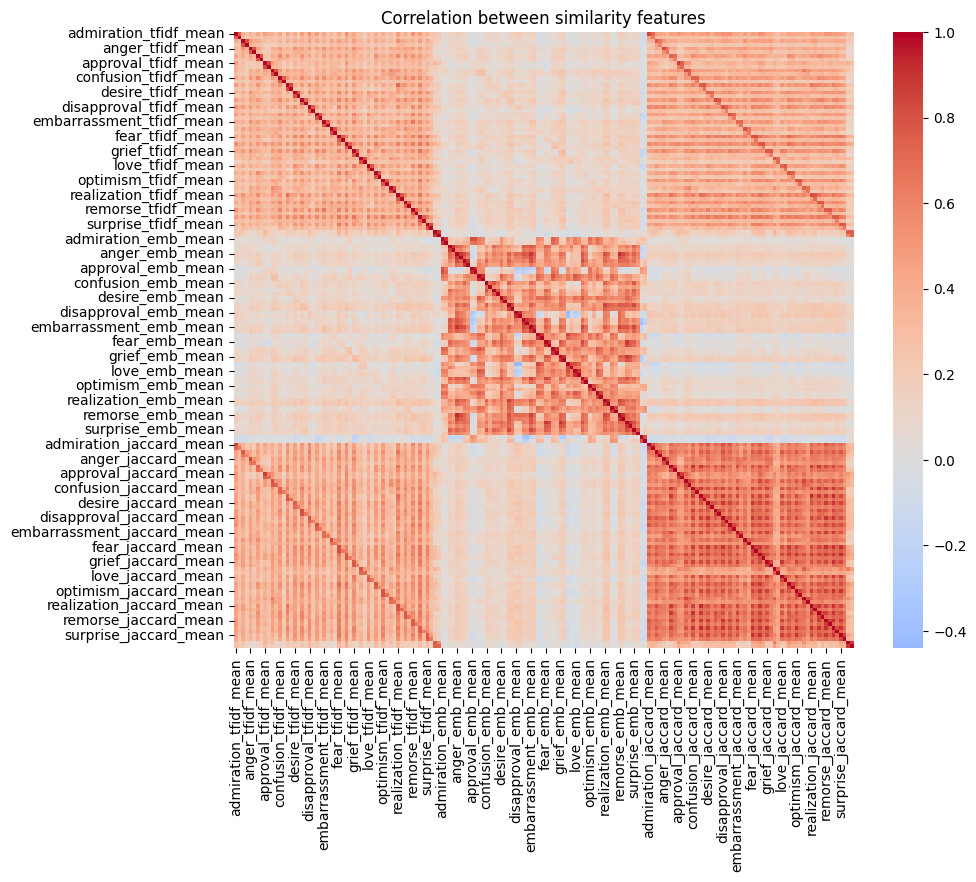

In [16]:
sample = df.sample(2000, random_state=42)

corr = sample[[c for c in df.columns if "_tfidf_" in c or "_emb_" in c or "_jaccard_" in c]].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation between similarity features")
plt.show()